In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import pandas as pd

In [7]:
def get_alamode_phband(alamode_bands: str):
    """
    Return: k-axis and eigenvalues in cm^-1
    """
    data = np.loadtxt(alamode_bands, skiprows=3)
    return data

def get_brillouin(alamode_bands: str):
    with open(alamode_bands) as f:
        high_symmetry_labels: str = f.readline().strip()
        high_symmetry_points: str = f.readline().strip()

    xticks: list[float] = [float(x) for x in high_symmetry_points.lstrip("#").split()]
    labels: list[str] = high_symmetry_labels.lstrip("#").split()

    xtick_labels = []
    for lab in labels:
        if lab == "G":
            xtick_labels.append(r"$\Gamma$")
        else:
            xtick_labels.append(f"{lab}")

    return xticks, xtick_labels


def plot_sym_lines(ax, x_coords):
    for x in x_coords:
        ax.axvline(x, c="gray", alpha=0.5, ls="--")

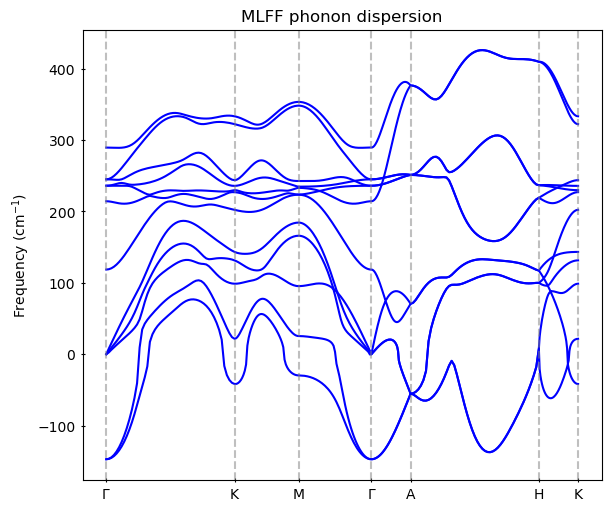

In [9]:
alamode_bands = "../alamode_phonons/mlff-phonons/zno_aenet.bands"
ph_data = get_alamode_phband(alamode_bands=alamode_bands)
xticks, xlabels = get_brillouin(alamode_bands)

q = ph_data[:, 0]
freq = ph_data[:, 1:] # cm^-1

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
ax.set_title("MLFF phonon dispersion")
ax.set_ylabel(r"Frequency (cm$^{-1}$)")
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)


for i in range(freq.shape[1]):
    ax.plot(q, freq[:, i], color="blue")

plot_sym_lines(ax, xticks)

ax.tick_params(axis="both", direction="inout")
plt.show()